# 🧠 Introduction to Neural Networks (الشبكات العصبية)
**Day 4 — Modern ML & the Bigger Picture**

---

## The Bridge from Day 1

On Day 1 you saw this equation:

$$\hat{y} = b + w_1 x_1 + w_2 x_2 + w_3 x_3$$

A neural network is this equation — repeated millions of times, stacked in layers, with one small addition: an **activation function** that introduces nonlinearity.

That's it. There's no new math. Just scale and structure.

In this notebook:
- Build intuition for the single neuron (the smallest possible neural network)
- Visualize activation functions and why they matter
- Build and train a neural network with Keras
- Understand training curves (loss and accuracy over epochs)

In [1]:
# Install keras/tensorflow if needed
try:
    import tensorflow as tf
    print("TensorFlow version:", tf.__version__)
except ImportError:
    import subprocess
    subprocess.run(["pip", "install", "tensorflow", "--quiet"])
    import tensorflow as tf
    print("TensorFlow installed:", tf.__version__)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits, make_moons
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
import warnings; warnings.filterwarnings("ignore")
np.random.seed(42)
tf.random.set_seed(42)
print("All imports ready ✓")

TensorFlow version: 2.21.0
All imports ready ✓


## Part 1 — The Single Neuron

A single neuron computes a weighted sum of its inputs, adds a bias, and passes the result through an activation function:

$$a = \phi(\mathbf{w}^T \mathbf{x} + b)$$

Let's visualize the most common activation functions.

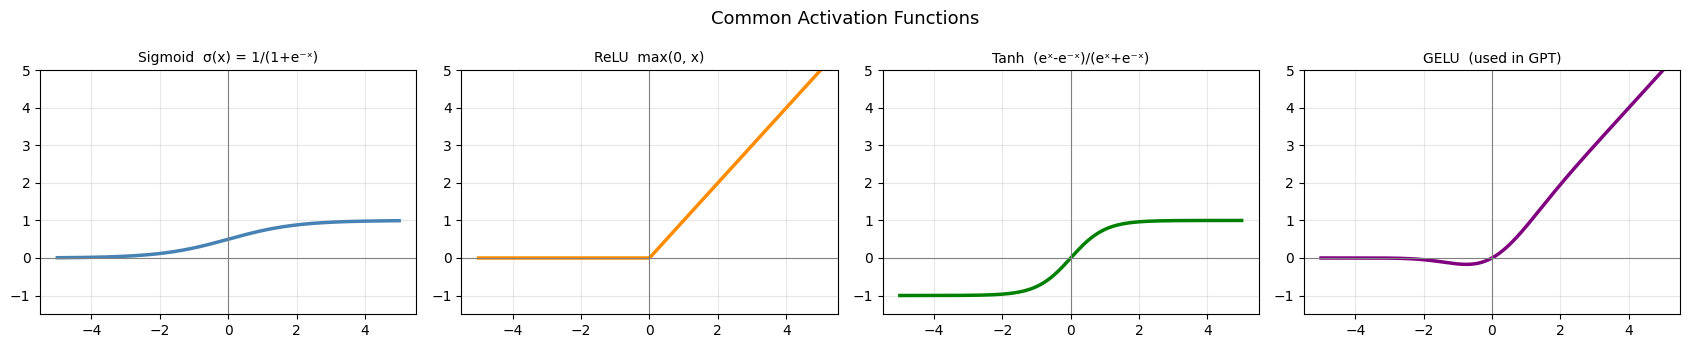

Key insight: without activation functions, stacking layers does nothing.
Any linear combination of linear functions is still linear.
Activation functions are what let neural networks learn curves and complex boundaries.


In [2]:
x = np.linspace(-5, 5, 200)

activations = {
    "Sigmoid  σ(x) = 1/(1+e⁻ˣ)": 1 / (1 + np.exp(-x)),
    "ReLU  max(0, x)":              np.maximum(0, x),
    "Tanh  (eˣ-e⁻ˣ)/(eˣ+e⁻ˣ)":  np.tanh(x),
    "GELU  (used in GPT)":          x * (1 + np.tanh(np.sqrt(2/np.pi) * (x + 0.044715*x**3))) / 2,
}

fig, axes = plt.subplots(1, 4, figsize=(17, 3.5))
colors = ["steelblue", "darkorange", "green", "purple"]

for ax, (name, y), color in zip(axes, activations.items(), colors):
    ax.plot(x, y, color=color, linewidth=2.5)
    ax.axhline(0, color="grey", linewidth=0.8)
    ax.axvline(0, color="grey", linewidth=0.8)
    ax.set_title(name, fontsize=10)
    ax.set_ylim(-1.5, 5)
    ax.grid(True, alpha=0.3)

plt.suptitle("Common Activation Functions", fontsize=13)
plt.tight_layout()
plt.show()

print("Key insight: without activation functions, stacking layers does nothing.")
print("Any linear combination of linear functions is still linear.")
print("Activation functions are what let neural networks learn curves and complex boundaries.")

## Part 2 — Why Depth Matters

A single layer can learn simple patterns. Multiple layers learn *hierarchical* patterns:
- Layer 1: detects simple features (edges in images, common words in text)
- Layer 2: combines simple features into patterns (curves, phrases)
- Layer 3: combines patterns into high-level concepts (faces, sentiment)

Let's see this in action on a non-linearly separable dataset (the "moons" dataset).

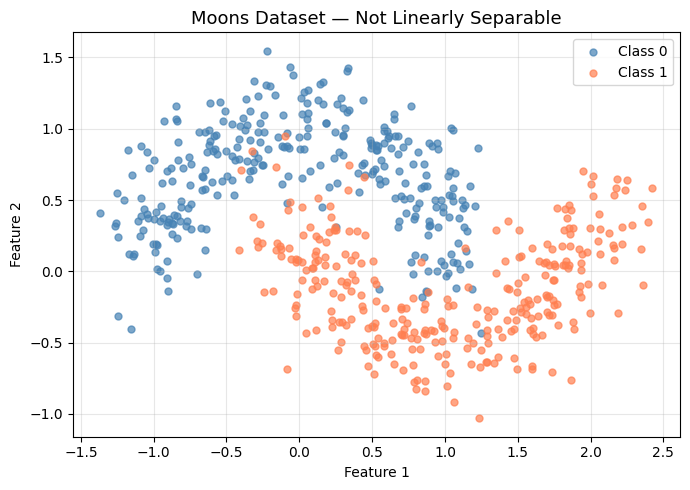

No single straight line can separate the two classes.
A neural network with hidden layers can learn the curved boundary.


In [3]:
# XOR-like dataset: not separable by a straight line
X_moons, y_moons = make_moons(n_samples=600, noise=0.2, random_state=42)

# Show the raw data
plt.figure(figsize=(7, 5))
for cls, color, label in [(0, "steelblue", "Class 0"), (1, "coral", "Class 1")]:
    mask = y_moons == cls
    plt.scatter(X_moons[mask, 0], X_moons[mask, 1], c=color, s=25, alpha=0.7, label=label)
plt.title("Moons Dataset — Not Linearly Separable", fontsize=13)
plt.xlabel("Feature 1"); plt.ylabel("Feature 2")
plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()

print("No single straight line can separate the two classes.")
print("A neural network with hidden layers can learn the curved boundary.")

In [4]:
# Build and train a neural network on the moons dataset
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

X_tr, X_te, y_tr, y_te = train_test_split(X_moons, y_moons, test_size=0.2, random_state=42)

model_moons = Sequential([
    Dense(16, activation="relu", input_shape=(2,)),   # Hidden layer 1
    Dense(8,  activation="relu"),                      # Hidden layer 2
    Dense(1,  activation="sigmoid"),                   # Output (probability)
])

model_moons.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
model_moons.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │            48 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 193 (772.00 B)

 Trainable params: 193 (772.00 B)

 Non-trainable params: 0 (0.00 B)

Test Accuracy: 90.0%


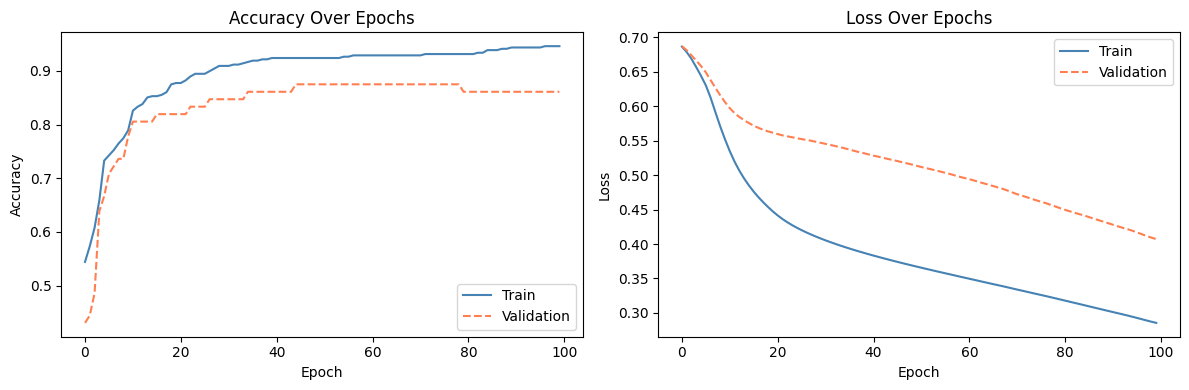


Reading training curves:
  - Both curves declining = model is learning
  - Large gap between train and val = overfitting
  - Both curves plateau = training has converged


In [5]:
# Train for 100 epochs
history_moons = model_moons.fit(
    X_tr, y_tr, epochs=100, batch_size=32,
    validation_split=0.15, verbose=0,
)

# Evaluate
test_loss, test_acc = model_moons.evaluate(X_te, y_te, verbose=0)
print(f"Test Accuracy: {test_acc:.1%}")

# Plot training curves
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history_moons.history["accuracy"],     label="Train",      color="steelblue")
axes[0].plot(history_moons.history["val_accuracy"], label="Validation", color="coral", linestyle="--")
axes[0].set_title("Accuracy Over Epochs", fontsize=12)
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Accuracy"); axes[0].legend()

axes[1].plot(history_moons.history["loss"],     label="Train",      color="steelblue")
axes[1].plot(history_moons.history["val_loss"], label="Validation", color="coral", linestyle="--")
axes[1].set_title("Loss Over Epochs", fontsize=12)
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Loss"); axes[1].legend()

plt.tight_layout(); plt.show()

print()
print("Reading training curves:")
print("  - Both curves declining = model is learning")
print("  - Large gap between train and val = overfitting")
print("  - Both curves plateau = training has converged")

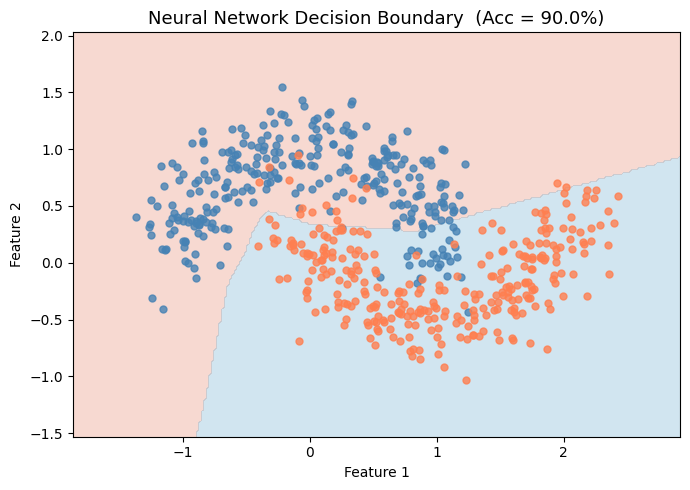

The neural network learned a curved boundary that a linear model could not.


In [6]:
# Visualize the learned decision boundary
def plot_decision_boundary(model, X, y, title=""):
    h = 0.02
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
    grid = np.c_[xx.ravel(), yy.ravel()]
    Z = (model.predict(grid, verbose=0) > 0.5).reshape(xx.shape)

    plt.figure(figsize=(7, 5))
    plt.contourf(xx, yy, Z, alpha=0.3, cmap="RdBu")
    for cls, color in [(0, "steelblue"), (1, "coral")]:
        mask = y == cls
        plt.scatter(X[mask, 0], X[mask, 1], c=color, s=25, alpha=0.8)
    plt.title(title, fontsize=13); plt.xlabel("Feature 1"); plt.ylabel("Feature 2")
    plt.tight_layout(); plt.show()

plot_decision_boundary(model_moons, X_moons, y_moons,
    title=f"Neural Network Decision Boundary  (Acc = {test_acc:.1%})")
print("The neural network learned a curved boundary that a linear model could not.")

## Part 3 — Digit Recognition (A Classic Benchmark)

MNIST-style digit recognition is "Hello, World" for Neural Networks (الشبكات العصبية). We'll use the sklearn digits dataset (8×8 grayscale images of handwritten digits 0–9).

Dataset: 1797 images, each 8×8 pixels
Classes: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9)] (0–9)


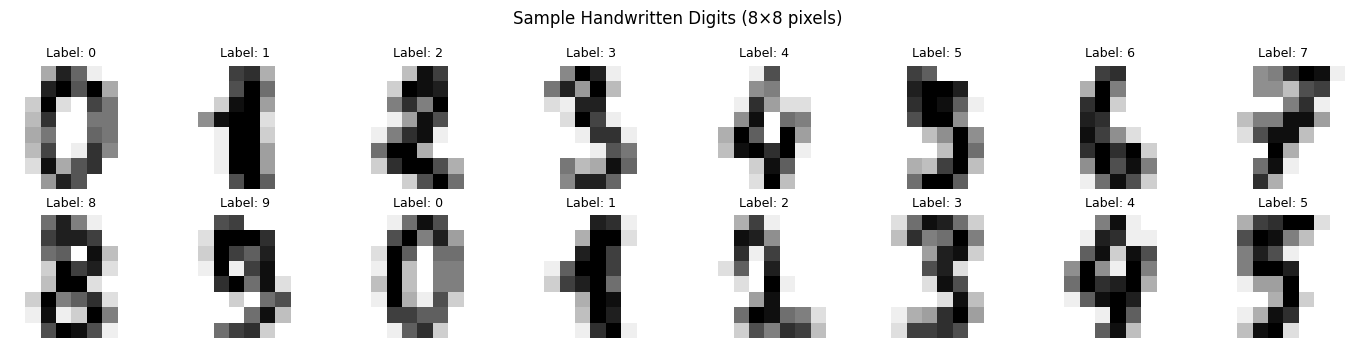

In [7]:
# Load digits dataset
digits = load_digits()
X_dig, y_dig = digits.data, digits.target  # 1797 × 64 (each image = 8×8 = 64 pixels)

print(f"Dataset: {X_dig.shape[0]} images, each {digits.images[0].shape[0]}×{digits.images[0].shape[1]} pixels")
print(f"Classes: {sorted(np.unique(y_dig))} (0–9)")

# Show sample images
fig, axes = plt.subplots(2, 8, figsize=(14, 3.5))
for i, ax in enumerate(axes.flat):
    ax.imshow(digits.images[i], cmap="grey_r")
    ax.set_title(f"Label: {digits.target[i]}", fontsize=9)
    ax.axis("off")
plt.suptitle("Sample Handwritten Digits (8×8 pixels)", fontsize=12)
plt.tight_layout(); plt.show()

In [8]:
# Build and train a digit classifier
X_tr_d, X_te_d, y_tr_d, y_te_d = train_test_split(X_dig, y_dig, test_size=0.2, random_state=42)

scaler_d = StandardScaler()
X_tr_ds = scaler_d.fit_transform(X_tr_d)
X_te_ds = scaler_d.transform(X_te_d)

model_digits = Sequential([
    Dense(128, activation="relu", input_shape=(64,)),
    Dense(64,  activation="relu"),
    Dense(10,  activation="softmax"),  # 10 output neurons — one per digit
])

model_digits.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
print("Model architecture:")
model_digits.summary()

Model architecture:


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,226 (67.29 KB)

 Trainable params: 17,226 (67.29 KB)

 Non-trainable params: 0 (0.00 B)


Digit recognition accuracy: 98.1%


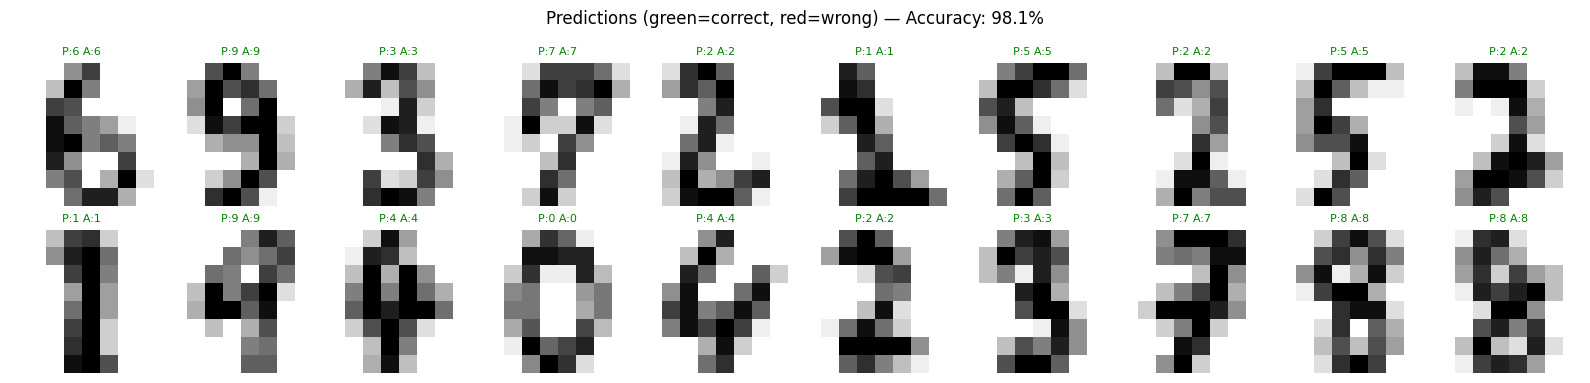

In [9]:
history_digits = model_digits.fit(
    X_tr_ds, y_tr_d, epochs=50, batch_size=32,
    validation_split=0.15, verbose=0,
)

test_loss_d, test_acc_d = model_digits.evaluate(X_te_ds, y_te_d, verbose=0)
print(f"\nDigit recognition accuracy: {test_acc_d:.1%}")

# Visualize predictions
y_pred_d = np.argmax(model_digits.predict(X_te_ds, verbose=0), axis=1)

fig, axes = plt.subplots(2, 10, figsize=(16, 4))
for i, ax in enumerate(axes.flat):
    ax.imshow(X_te_d[i].reshape(8, 8), cmap="grey_r")
    color = "green" if y_pred_d[i] == y_te_d[i] else "red"
    ax.set_title(f"P:{y_pred_d[i]} A:{y_te_d[i]}", fontsize=8, color=color)
    ax.axis("off")
plt.suptitle(f"Predictions (green=correct, red=wrong) — Accuracy: {test_acc_d:.1%}", fontsize=12)
plt.tight_layout(); plt.show()

---

## Key Takeaways

- A **neuron** computes: weighted sum + bias → activation function → output
- **Activation functions** (ReLU, sigmoid, softmax) introduce nonlinearity — essential for complex patterns
- **Deep** = multiple hidden layers → hierarchical feature learning
- Training: minimize loss by adjusting weights/biases via **gradient descent**
- **Training curves**: loss should decrease; large train/val gap = overfitting

**In Day 1's Linear Regression (الانحدار الخطي) terms:**
- Weights in Linear Regression (الانحدار الخطي) = weights in a neural network
- The neural network just has millions more of them, stacked in layers
- The fundamental idea — minimize error, update parameters — is identical

# Module 2: Deep Learning (التعلم العميق) Primer

## Learning Objectives
By the end of this module, you will be able to:
- Understand the fundamental concepts of Neural Networks (الشبكات العصبية)
- Recognize common neural network architectures
- Understand how networks learn through gradient descent and backpropagation
- Build a simple image classifier with TensorFlow/Keras

---

## 1. From ML to Deep Learning (التعلم العميق)

### What Makes Deep Learning (التعلم العميق) "Deep"?

**Traditional Machine Learning (التعلم الآلي):**
- Requires manual **Feature Engineering (هندسة الميزات)** (humans decide what patterns to look for)
- Works well with structured, tabular data
- Limited ability to handle raw data like images, audio, text

**Deep Learning (التعلم العميق):**
- **Automatic feature learning** from raw data
- Uses multiple layers (hence "deep") to learn hierarchical representations
- Excels at unstructured data: images, speech, text, video

```
Image → [Low-level: edges] → [Mid-level: shapes] → [High-level: objects] → "Cat"
Text  → [Characters] → [Words] → [Phrases] → [Meaning/Context]
```

### When to Use Deep Learning (التعلم العميق)?

| Use Traditional ML | Use Deep Learning (التعلم العميق) |
|-------------------|-------------------|
| Small datasets (<10K samples) | Large datasets (100K+) |
| Structured/tabular data | Unstructured data (images, text, audio) |
| Need interpretability | Performance is priority |
| Limited compute resources | Have GPUs available |

---

## 2. The Artificial Neuron

### Inspired by Biology

An artificial neuron mimics (loosely) how biological neurons work:

```
Biological:  Dendrites → Cell Body → Axon → Synapses
Artificial:  Inputs → Weighted Sum → Activation → Output
```

### Mathematical Model

```
                    ┌─────────────────────┐
     x₁ ──w₁──▶    │                     │
     x₂ ──w₂──▶    │  z = Σ(wᵢ·xᵢ) + b  │ ──▶ a = σ(z) ──▶ output
     x₃ ──w₃──▶    │                     │
          ⬆        └─────────────────────┘
        bias (b)
```

Where:
- **xᵢ**: Input features
- **wᵢ**: Weights (learnable parameters)
- **b**: Bias (another learnable parameter)
- **σ**: Activation function (introduces non-linearity)

### Activation Functions

Without activation functions, a neural network would just be linear transformations stacked together (equivalent to a single linear function). Activations introduce **non-linearity**:

- **ReLU** (Rectified Linear Unit): `max(0, x)` - Most common
- **Sigmoid**: `1 / (1 + e^(-x))` - Output between 0 and 1
- **Tanh**: `(e^x - e^(-x)) / (e^x + e^(-x))` - Output between -1 and 1
- **Softmax**: Converts outputs to probability distribution

In [ ]:
# Install required packages
!uv pip install -q tensorflow matplotlib numpy

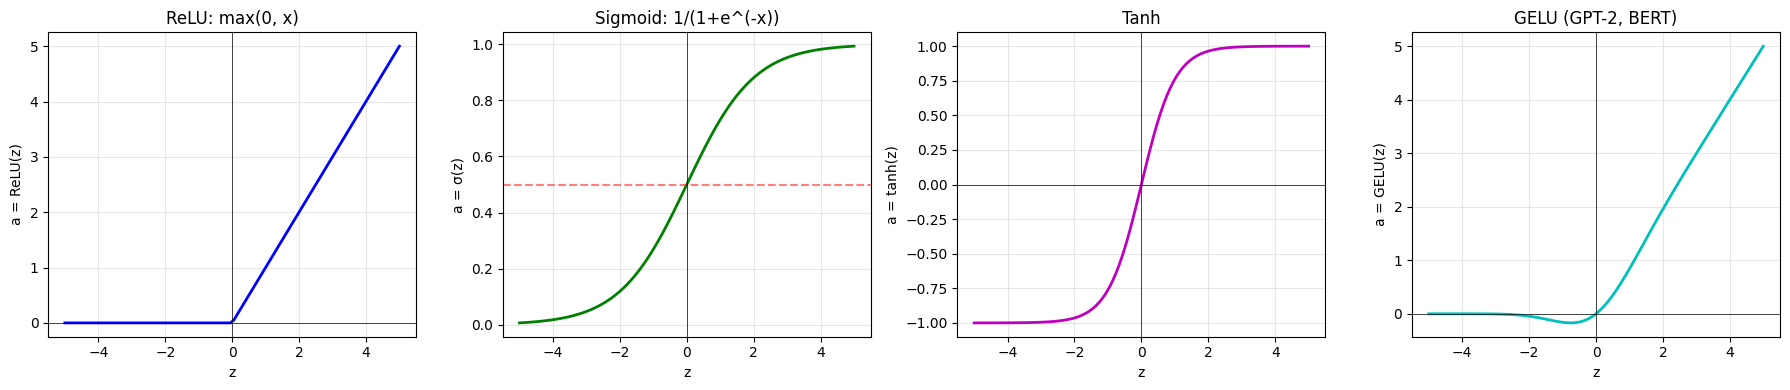

💡 ReLU: simple and fast. GELU: smooth variant used in GPT-2, BERT, and all modern LLMs — you'll see it again in Module 05!


In [13]:
import numpy as np
import matplotlib.pyplot as plt

# Visualize activation functions
x = np.linspace(-5, 5, 100)

# Define activation functions
relu = np.maximum(0, x)
sigmoid = 1 / (1 + np.exp(-x))
tanh = np.tanh(x)
# GELU: Gaussian Error Linear Unit — standard in GPT-2, BERT, and modern LLMs
gelu = 0.5 * x * (1 + np.tanh(np.sqrt(2 / np.pi) * (x + 0.044715 * x**3)))

fig, axes = plt.subplots(1, 4, figsize=(18, 4))

axes[0].plot(x, relu, 'b-', linewidth=2)
axes[0].axhline(y=0, color='k', linestyle='-', linewidth=0.5)
axes[0].axvline(x=0, color='k', linestyle='-', linewidth=0.5)
axes[0].set_title('ReLU: max(0, x)', fontsize=12)
axes[0].set_xlabel('z')
axes[0].set_ylabel('a = ReLU(z)')
axes[0].grid(True, alpha=0.3)

axes[1].plot(x, sigmoid, 'g-', linewidth=2)
axes[1].axhline(y=0.5, color='r', linestyle='--', alpha=0.5)
axes[1].axvline(x=0, color='k', linestyle='-', linewidth=0.5)
axes[1].set_title('Sigmoid: 1/(1+e^(-x))', fontsize=12)
axes[1].set_xlabel('z')
axes[1].set_ylabel('a = σ(z)')
axes[1].grid(True, alpha=0.3)

axes[2].plot(x, tanh, 'm-', linewidth=2)
axes[2].axhline(y=0, color='k', linestyle='-', linewidth=0.5)
axes[2].axvline(x=0, color='k', linestyle='-', linewidth=0.5)
axes[2].set_title('Tanh', fontsize=12)
axes[2].set_xlabel('z')
axes[2].set_ylabel('a = tanh(z)')
axes[2].grid(True, alpha=0.3)

axes[3].plot(x, gelu, 'c-', linewidth=2)
axes[3].axhline(y=0, color='k', linestyle='-', linewidth=0.5)
axes[3].axvline(x=0, color='k', linestyle='-', linewidth=0.5)
axes[3].set_title('GELU (GPT-2, BERT)', fontsize=12)
axes[3].set_xlabel('z')
axes[3].set_ylabel('a = GELU(z)')
axes[3].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("💡 ReLU: simple and fast. GELU: smooth variant used in GPT-2, BERT, and all modern LLMs — you'll see it again in Module 05!")

---

## Why Activation Functions Exist — and What Each One Does

### The Problem Without Them

Without activation functions, a neural network — no matter how many layers deep — collapses into a single linear equation. Mathematically:

```
Layer 1:  output = W₁ · input + b₁
Layer 2:  output = W₂ · (W₁ · input + b₁) + b₂
        = (W₂W₁) · input + (W₂b₁ + b₂)
        = W_combined · input + b_combined
```

No matter how many layers you stack, **the result is still just one linear transformation** — equivalent to a single-layer model (like logistic regression). You get depth without power.

**Activation functions break this linearity.** They let the network learn curves, boundaries, and complex patterns — things that a straight line can never fit.

> 💡 **Analogy:** Imagine trying to separate cats from dogs by drawing only straight lines through a scatter plot. Some problems need curves. Activation functions are what give the network the ability to draw those curves.

---

### Activation Functions: Plain-Language Guide

#### 🔵 ReLU (Rectified Linear Unit)
**Simple rule:** *"If the input is negative, output 0. If it's positive, pass it through unchanged."*

```
f(x) = max(0, x)

x = -3  →  f(x) = 0
x =  5  →  f(x) = 5
```

Fast to compute, avoids the vanishing gradient problem that plagued older networks. The default choice for hidden layers in most modern networks.

---

#### 🟢 Sigmoid
**Simple rule:** *"Squeeze any input into a probability between 0 and 1."*

```
f(x) = 1 / (1 + e^(-x))

x = -5  →  f(x) ≈ 0.007  (close to 0)
x =  0  →  f(x) = 0.5
x = +5  →  f(x) ≈ 0.993  (close to 1)
```

Historically important, but has a problem: for very large or very small inputs, gradients become nearly zero ("vanishing gradient"), slowing learning. Avoided in hidden layers of modern networks.

---

#### 🟡 Tanh (Hyperbolic Tangent)
**Simple rule:** *"Like sigmoid, but scaled to output between -1 and +1, centered at zero."*

```
f(x) = (e^x - e^(-x)) / (e^x + e^(-x))

x = -5  →  f(x) ≈ -1
x =  0  →  f(x) =  0
x = +5  →  f(x) ≈ +1
```

Better than sigmoid for hidden layers because it's zero-centered, which makes training more stable. Still has the vanishing gradient issue at extremes.

---

#### 🔴 GELU (Gaussian Error Linear Unit)
**Simple rule:** *"Like ReLU, but with a smooth curve at zero instead of a hard corner — inputs near zero are gated probabilistically."*

```
f(x) ≈ x · Φ(x)     where Φ is the standard normal CDF

x = -2  →  f(x) ≈ -0.04  (mostly suppressed)
x =  0  →  f(x) =  0
x = +2  →  f(x) ≈  1.95  (mostly passed through)
```

The standard activation in **BERT**, **GPT-2**, and most modern transformer-based LLMs. Smooth differentiability leads to better gradient flow during training.

---

### Quick Reference: When Is Each Used?

| Activation | Plain-language behavior | Most common use | Notes |
|------------|------------------------|-----------------|-------|
| **ReLU** | Zero if negative, pass-through if positive | Hidden layers in CNNs, dense networks | Default choice; fast; can cause "dead neurons" |
| **Sigmoid** | Squishes to (0, 1) | **Binary Classification (التصنيف) output layer** | Maps to a probability; avoid in hidden layers |
| **Tanh** | Squishes to (-1, 1) | RNNs & LSTMs; some hidden layers | Zero-centered; better than sigmoid for hidden layers |
| **GELU** | Smooth ReLU variant | **Transformer hidden layers** (BERT, GPT, LLaMA) | Standard in modern LLMs |
| **Softmax** *(not shown above)* | Turns scores into probabilities that sum to 1 | **Multi-class Classification (التصنيف) output layer** | Always used as the final layer for 3+ classes |

> 📌 **Rule of thumb for choosing:**
> - Hidden layers in a standard network → **ReLU**
> - Binary yes/no output → **Sigmoid**
> - 3+ class output → **Softmax**
> - Building or fine-tuning a transformer → **GELU** (it's already baked in)


---

## 3. Neural Network Architecture

A neural network is layers of neurons connected together:

```
Input Layer          Hidden Layers              Output Layer
    ○                    ○    ○                     ○
    ○ ──────────────▶    ○    ○  ──────────────▶    ○
    ○                    ○    ○                     ○
    ○                    ○    ○                     
(features)           (learned                   (predictions)
                    representations)
```

### Common Architectures

| Architecture | Best For | Key Idea |
|-------------|----------|----------|
| **Dense/MLP** | Tabular data, simple tasks | Fully connected layers |
| **CNN** | Images, spatial data | Convolutions detect local patterns |
| **RNN/LSTM** | Sequences, time series | Memory of previous inputs |
| **Transformer** | Text, long sequences | Attention mechanism (GPT, BERT) |

> **🔑 For Generative AI (الذكاء الاصطناعي التوليدي):** Transformers are the foundation of modern LLMs (GPT, BERT, LLaMA, Claude)

---

## 4. How Neural Networks (الشبكات العصبية) Learn

### The Learning Loop

```
┌─────────────────────────────────────────────────────────────┐
│  1. FORWARD PASS                                            │
│     Input → Network → Prediction                            │
│                                                             │
│  2. LOSS CALCULATION                                        │
│     How wrong was the prediction? (Loss = f(prediction, y)) │
│                                                             │
│  3. BACKWARD PASS (Backpropagation)                         │
│     Calculate gradients: ∂Loss/∂weights                     │
│                                                             │
│  4. UPDATE WEIGHTS (Gradient Descent)                       │
│     weights = weights - learning_rate × gradient            │
│                                                             │
│  Repeat for many iterations (epochs)                        │
└─────────────────────────────────────────────────────────────┘
```

### Key Concepts

**Loss Function:** Measures how wrong predictions are
- Classification (التصنيف): Cross-entropy loss
- Regression: Mean squared error

**Gradient Descent:** Finds the direction to adjust weights to reduce loss
- Think of it as rolling downhill on the loss landscape

**Learning Rate:** How big of steps to take
- Too high: Overshoots optimal values
- Too low: Training takes forever

**Backpropagation:** Efficiently computes gradients using chain rule

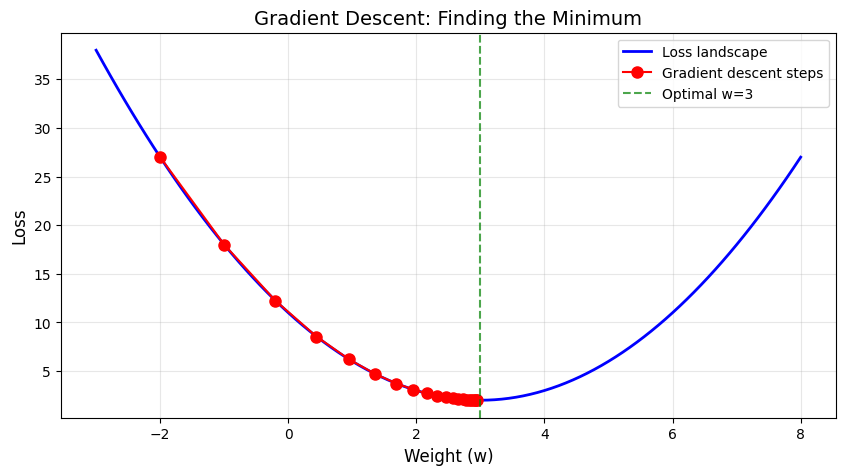

Started at w=-2.00, converged to w=2.94
Optimal value is w=3.00


In [14]:
# Visualizing Gradient Descent on a simple loss landscape
def loss_function(w):
    """Simple quadratic loss function"""
    return (w - 3) ** 2 + 2

def gradient(w):
    """Derivative of loss function"""
    return 2 * (w - 3)

# Gradient descent simulation
w = -2  # Starting point
learning_rate = 0.1
history = [w]

for _ in range(20):
    grad = gradient(w)
    w = w - learning_rate * grad  # Update rule
    history.append(w)

# Visualize
w_range = np.linspace(-3, 8, 100)
loss_values = loss_function(w_range)

plt.figure(figsize=(10, 5))
plt.plot(w_range, loss_values, 'b-', linewidth=2, label='Loss landscape')
plt.plot(history, [loss_function(w) for w in history], 'ro-', markersize=8, label='Gradient descent steps')
plt.axvline(x=3, color='g', linestyle='--', alpha=0.7, label='Optimal w=3')
plt.xlabel('Weight (w)', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.title('Gradient Descent: Finding the Minimum', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"Started at w={history[0]:.2f}, converged to w={history[-1]:.2f}")
print(f"Optimal value is w=3.00")

---

## 5. Optional Demo: TensorFlow Playground

🎮 **Interactive Exploration:**

Visit [TensorFlow Playground](https://playground.tensorflow.org/) to:

1. See how adding layers and neurons affects learning
2. Experiment with different activation functions
3. Watch the decision boundary evolve during training
4. Understand feature learning visually

**Try These Experiments:**
1. Start with the spiral dataset and 1 hidden layer - can you fit it?
2. Add more layers - how does it change?
3. Try ReLU vs Sigmoid - which learns faster?
4. What happens with too high learning rate?

---

## 6. Hands-On: Image Classification (التصنيف) with TensorFlow

Let's build a neural network to classify handwritten digits (MNIST dataset).

MNIST contains 70,000 grayscale images of digits 0-9, each 28×28 pixels.

TensorFlow version: 2.20.0

📊 Dataset loaded:
   Training samples: 60000
   Test samples: 10000
   Image shape: (28, 28) (28×28 pixels, grayscale)


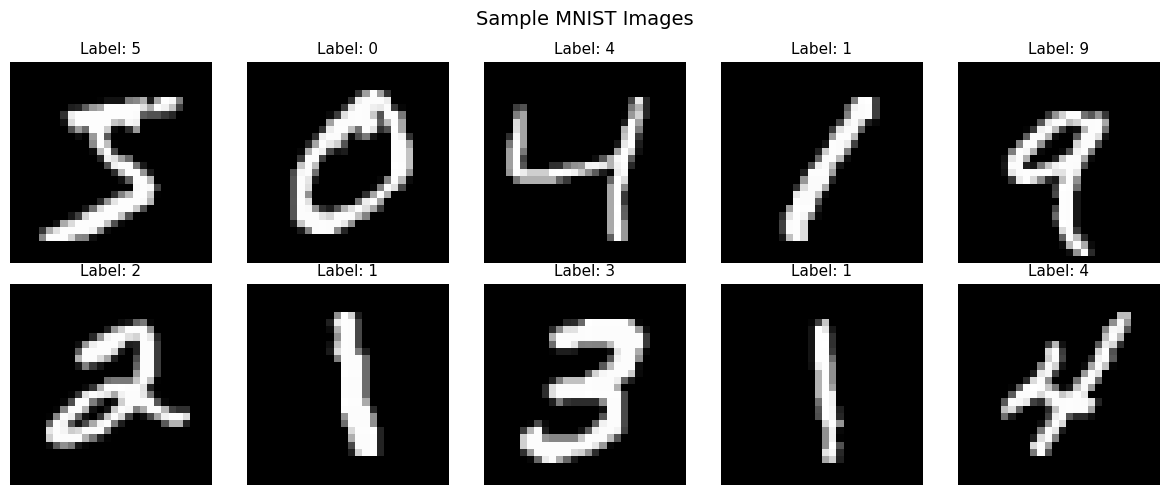

In [15]:
import tensorflow as tf
import keras
from keras import layers

print(f"TensorFlow version: {tf.__version__}")

# Load MNIST dataset
(X_train, y_train), (X_test, y_test) = keras.datasets.mnist.load_data()

print(f"\n📊 Dataset loaded:")
print(f"   Training samples: {X_train.shape[0]}")
print(f"   Test samples: {X_test.shape[0]}")
print(f"   Image shape: {X_train.shape[1:]} (28×28 pixels, grayscale)")

# Visualize some samples
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, ax in enumerate(axes.flat):
    ax.imshow(X_train[i], cmap='gray')
    ax.set_title(f'Label: {y_train[i]}', fontsize=11)
    ax.axis('off')
plt.suptitle('Sample MNIST Images', fontsize=14)
plt.tight_layout()
plt.show()

In [16]:
# Preprocess the data

# 1. Normalize pixel values to 0-1 range (originally 0-255)
X_train = X_train.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0

# 2. Flatten images from 28×28 to 784-dimensional vectors
#    (for our simple dense network)
X_train_flat = X_train.reshape(-1, 28 * 28)
X_test_flat = X_test.reshape(-1, 28 * 28)

print(f"Preprocessed shapes:")
print(f"  X_train: {X_train_flat.shape}")
print(f"  X_test: {X_test_flat.shape}")

Preprocessed shapes:
  X_train: (60000, 784)
  X_test: (10000, 784)


In [17]:
# Build the Neural Network

model = keras.Sequential([
    # Input layer (784 features = 28×28 pixels)
    layers.Input(shape=(784,)),
    
    # Hidden layer 1: 128 neurons with ReLU activation
    layers.Dense(128, activation='relu', name='hidden_1'),
    
    # Hidden layer 2: 64 neurons with ReLU activation  
    layers.Dense(64, activation='relu', name='hidden_2'),
    
    # Output layer: 10 neurons (one per digit) with softmax for probabilities
    layers.Dense(10, activation='softmax', name='output')
])

# Display model architecture
model.summary()

print("\n💡 Total parameters to learn:", model.count_params())

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ hidden_1 (Dense)                │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_2 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)


💡 Total parameters to learn: 109386


In [18]:
# Compile the model
model.compile(
    optimizer='adam',  # Popular adaptive optimizer
    loss='sparse_categorical_crossentropy',  # For multi-class classification
    metrics=['accuracy']
)

print("✅ Model compiled!")
print("   Optimizer: Adam (adaptive learning rate)")
print("   Loss: Sparse Categorical Crossentropy")
print("   Metric: Accuracy")

✅ Model compiled!
   Optimizer: Adam (adaptive learning rate)
   Loss: Sparse Categorical Crossentropy
   Metric: Accuracy


In [19]:
# Train the model
print("🎓 Training the neural network...\n")

# Production tip: use EarlyStopping to stop when val_loss stops improving:
#   from keras.callbacks import EarlyStopping
#   early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
#   model.fit(..., callbacks=[early_stop])
# You will use this pattern directly in Module 07 (fine-tuning).

history = model.fit(
    X_train_flat, y_train,
    epochs=10,  # Number of full passes through training data
    batch_size=32,  # How many samples per gradient update
    validation_split=0.1,  # Use 10% of training data for validation
    verbose=1
)

print("\n✅ Training complete!")

🎓 Training the neural network...

Epoch 1/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9272 - loss: 0.2451 - val_accuracy: 0.9713 - val_loss: 0.1044
Epoch 2/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9693 - loss: 0.1011 - val_accuracy: 0.9688 - val_loss: 0.1057
Epoch 3/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9773 - loss: 0.0714 - val_accuracy: 0.9765 - val_loss: 0.0803
Epoch 4/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9826 - loss: 0.0542 - val_accuracy: 0.9788 - val_loss: 0.0757
Epoch 5/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9856 - loss: 0.0448 - val_accuracy: 0.9783 - val_loss: 0.0751
Epoch 6/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9887 - loss: 0.0341 - val_accuracy: 0.9820 - val_loss: 0.0703
Epoch 7/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9897 - loss: 0.0307 - val_accuracy: 0.9757 - val_loss: 0.1022
Epoch 8/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - 

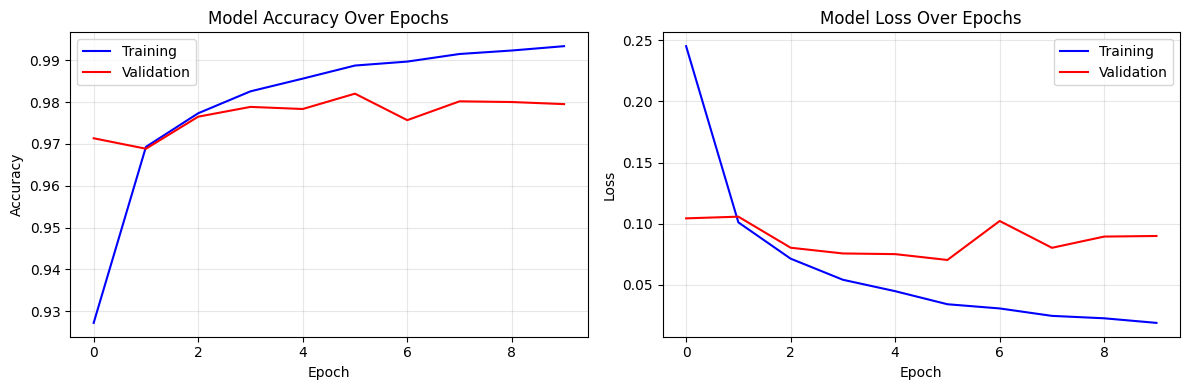

In [20]:
# Visualize training progress
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Accuracy plot
axes[0].plot(history.history['accuracy'], 'b-', label='Training')
axes[0].plot(history.history['val_accuracy'], 'r-', label='Validation')
axes[0].set_title('Model Accuracy Over Epochs', fontsize=12)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Loss plot
axes[1].plot(history.history['loss'], 'b-', label='Training')
axes[1].plot(history.history['val_loss'], 'r-', label='Validation')
axes[1].set_title('Model Loss Over Epochs', fontsize=12)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [21]:
# Evaluate on test set
test_loss, test_accuracy = model.evaluate(X_test_flat, y_test, verbose=0)

print(f"\nFinal Test Results:")
print(f"   Test Accuracy: {test_accuracy:.2%}")
print(f"   Test Loss: {test_loss:.4f}")


Final Test Results:
   Test Accuracy: 97.98%
   Test Loss: 0.0803


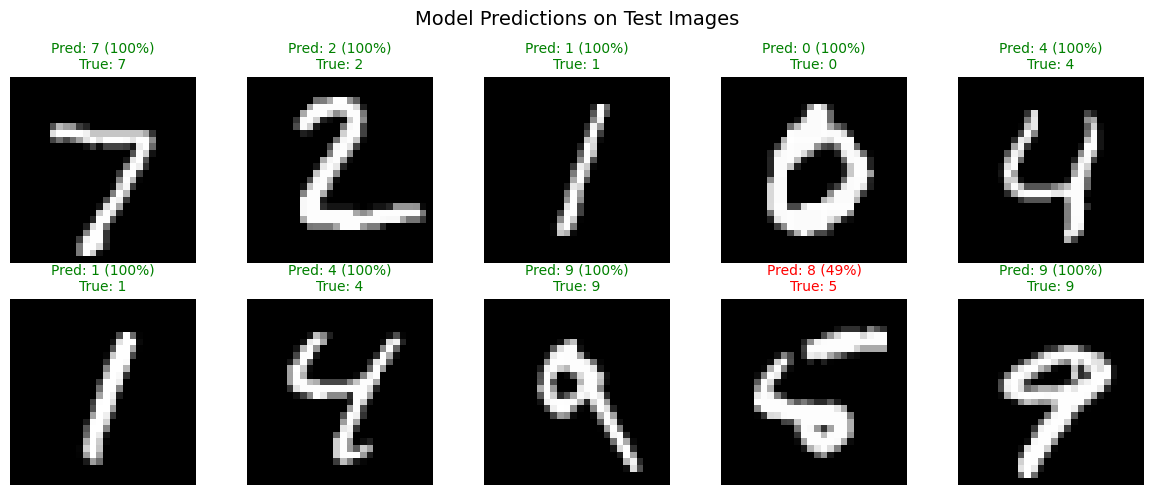

In [22]:
# Make predictions and visualize
predictions = model.predict(X_test_flat[:10], verbose=0)

fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, ax in enumerate(axes.flat):
    ax.imshow(X_test[i], cmap='gray')
    pred_digit = np.argmax(predictions[i])
    confidence = predictions[i][pred_digit]
    true_digit = y_test[i]
    
    color = 'green' if pred_digit == true_digit else 'red'
    ax.set_title(f'Pred: {pred_digit} ({confidence:.0%})\nTrue: {true_digit}', 
                 fontsize=10, color=color)
    ax.axis('off')

plt.suptitle('Model Predictions on Test Images', fontsize=14)
plt.tight_layout()
plt.show()

---

## 7. Why Deep Learning (التعلم العميق) Powers Generative AI (الذكاء الاصطناعي التوليدي)

The concepts we learned today are the foundation of LLMs and generative models:

| Deep Learning (التعلم العميق) Concept | Generative AI (الذكاء الاصطناعي التوليدي) Application |
|----------------------|---------------------------|
| Neural Networks (الشبكات العصبية) | GPT, BERT, LLaMA are massive Neural Networks (الشبكات العصبية) |
| Backpropagation | How LLMs are trained on text data |
| Loss functions | Next-word prediction loss for language models |
| Activation functions | Used throughout transformer architectures |
| Hidden layers | LLMs have dozens to hundreds of layers |
| Softmax | Converts outputs to probability over vocabulary |


### The Hidden Layer = A Latent Representation

Look at the last hidden layer before the softmax output in our MNIST classifier.
That 64-dimensional vector is not a pixel — it is a **learned representation** of the
digit. The network compressed a 784-pixel image into 64 numbers that capture what
makes a digit recognizable.

This is exactly the idea behind the **encoder** in a Variational Autoencoder (Module 03):
compress input into a compact latent representation, then decode it back. The VAE
bottleneck is a hidden layer. Stable Diffusion runs its denoising process entirely inside
a compressed latent space produced by a VAE encoder. The architecture you built today
is the conceptual ancestor of all of it.

### Scale Comparison

| Model | Parameters |
|-------|------------|
| Our MNIST classifier | ~109,000 |
| GPT-2 | 1.5 billion |
| GPT-3 | 175 billion |
| GPT-4 | ~1.7 trillion (estimated) |

---

## 📝 Student Exercise

### Challenge: Improve the MNIST Classifier

Try modifying the network architecture to improve accuracy:

1. Add more hidden layers
2. Change the number of neurons per layer
3. Try different activation functions
4. Add dropout for regularization
5. Train for more epochs

In [ ]:
# Student Challenge: Build an improved model

my_model = keras.Sequential([
    layers.Input(shape=(784,)),
    
    # TODO: Add your layers here
    # Try: More layers, different sizes, dropout, etc.
    # Example:
    # layers.Dense(256, activation='relu'),
    # layers.Dropout(0.3),  # Regularization
    # layers.Dense(128, activation='relu'),
    
    layers.Dense(10, activation='softmax')
])

# Compile and train
# my_model.compile(...)
# my_model.fit(...)

print("Complete the improved model above!")

### 💡 Solution: Improved MNIST Classifier

Below is an example solution that improves upon the basic model. This solution incorporates several techniques:

1. **Deeper architecture**: 3 hidden layers instead of 1
2. **Larger layers**: More neurons to learn complex patterns
3. **Dropout regularization**: Prevents overfitting by randomly dropping neurons during training
4. **ReLU activation**: Fast and effective for hidden layers
5. **Batch normalization**: Normalizes activations to zero mean and unit variance after each Dense layer — faster convergence, more stable training. Pattern: Dense → BatchNorm → Activation → Dropout

**Expected improvements:**
- Base model accuracy: ~97-98%
- Improved model accuracy: ~98-99%

In [23]:
# Solution: Improved MNIST Classifier

# Build improved model with deeper architecture
improved_model = keras.Sequential([
    layers.Input(shape=(784,)),
    
    # Layer 1: 256 neurons with BatchNorm + ReLU
    layers.Dense(256, name='hidden_1'),
    layers.BatchNormalization(),  # Normalize activations: faster, more stable training
    layers.Activation('relu'),
    layers.Dropout(0.3),

    # Layer 2: 128 neurons
    layers.Dense(128, name='hidden_2'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.Dropout(0.3),

    # Layer 3: 64 neurons
    layers.Dense(64, name='hidden_3'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.Dropout(0.2),
    
    # Output layer: 10 classes (digits 0-9)
    layers.Dense(10, activation='softmax', name='output')
])

# Display architecture
improved_model.summary()

# Compile with same configuration as base model
improved_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Train the improved model
print("\nTraining improved model...")
history_improved = improved_model.fit(
    X_train_flat, y_train,  # Use flattened data (784 features)
    epochs=15,  # More epochs to fully train the deeper model
    batch_size=128,
    validation_split=0.2,
    verbose=1
)

# Evaluate on test set
test_loss_improved, test_accuracy_improved = improved_model.evaluate(X_test_flat, y_test, verbose=0)
print(f"\n✅ Improved Model Test Accuracy: {test_accuracy_improved:.4f}")
print(f"   (Original model: ~0.9700-0.9800)")
print(f"   Improvement: ~{(test_accuracy_improved - 0.975) * 100:.2f}%")

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ hidden_1 (Dense)                │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_2 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_3 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 244,554 (955.29 KB)

 Trainable params: 243,658 (951.79 KB)

 Non-trainable params: 896 (3.50 KB)


Training improved model...
Epoch 1/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8528 - loss: 0.5171 - val_accuracy: 0.9523 - val_loss: 0.1613
Epoch 2/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9322 - loss: 0.2310 - val_accuracy: 0.9634 - val_loss: 0.1202
Epoch 3/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9479 - loss: 0.1777 - val_accuracy: 0.9697 - val_loss: 0.1024
Epoch 4/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9556 - loss: 0.1467 - val_accuracy: 0.9718 - val_loss: 0.0940
Epoch 5/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9610 - loss: 0.1283 - val_accuracy: 0.9755 - val_loss: 0.0856
Epoch 6/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9655 - loss: 0.1168 - val_accuracy: 0.9753 - val_loss: 0.0798
Epoch 7/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9695 - loss: 0.0995 - val_accuracy: 0.9734 - val_loss: 0.0866
Epoch 8/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9705 - los

### 📊 Explanation of Improvements

**1. Deeper Architecture (3 hidden layers)**
- More layers allow the network to learn more complex hierarchical features
- Layer 1 (256): Learns basic features (edges, curves)
- Layer 2 (128): Combines basic features into patterns (strokes, loops)
- Layer 3 (64): Learns high-level digit-specific features

**2. Dropout Regularization**
```python
layers.Dropout(0.3)  # Randomly drops 30% of connections
```
- **Purpose**: Prevents overfitting by forcing the network to learn robust features
- **How it works**: During training, randomly sets 30% of neuron outputs to 0
- **Decreasing dropout**: Use more dropout in early layers (0.3) and less in deeper layers (0.2)

**3. Neuron Count Strategy**
- Start with more neurons (256) and gradually decrease (128 → 64)
- This creates a "funnel" that compresses information toward the output
- Balances model capacity with computational efficiency

**4. Training Considerations**
- **More epochs (15)**: Deeper models need more time to converge
- **Validation split**: 20% of training data used to monitor overfitting
- **Batch size (128)**: Good balance between speed and stability

**5. Why These Choices?**

| Technique | Without It | With It |
|-----------|-----------|---------|
| Multiple layers | Can't learn complex patterns | Learns hierarchical features |
| Dropout | Overfits training data | Generalizes better to new data |
| More neurons | Underfits, misses patterns | Captures more detail |
| More epochs | Undertrained | Fully optimized |
| Batch normalization | Unstable training, slower convergence | Normalized activations, faster and more stable training |

**Common Mistakes to Avoid:**
- ❌ Too many layers: Harder to train, diminishing returns
- ❌ No dropout: Overfitting on training data
- ❌ Too few neurons: Underfitting, can't capture patterns
- ❌ Too much dropout (>0.5): Underfitting, throws away too much information

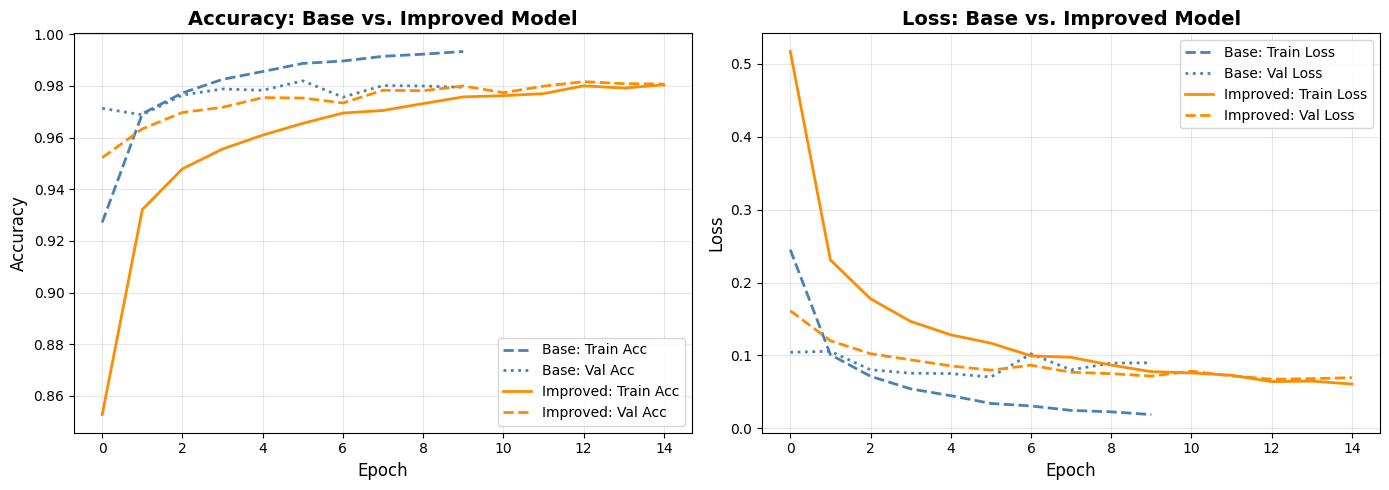


📈 Training Insights:
   Base model final val accuracy:     0.9795
   Improved model final val accuracy: 0.9808
   Improved model train/val gap:      0.0003

   Small gap (<0.02) = Good generalization
   Large gap (>0.05) = Overfitting


In [24]:
# Visualize training history: Base model vs. Improved model
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy — both models
ax1.plot(history.history['accuracy'], label='Base: Train Acc', linewidth=2, linestyle='--', color='steelblue')
ax1.plot(history.history['val_accuracy'], label='Base: Val Acc', linewidth=2, linestyle=':', color='steelblue')
ax1.plot(history_improved.history['accuracy'], label='Improved: Train Acc', linewidth=2, color='darkorange')
ax1.plot(history_improved.history['val_accuracy'], label='Improved: Val Acc', linewidth=2, linestyle='--', color='darkorange')
ax1.set_xlabel('Epoch', fontsize=12)
ax1.set_ylabel('Accuracy', fontsize=12)
ax1.set_title('Accuracy: Base vs. Improved Model', fontsize=14, fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Loss — both models
ax2.plot(history.history['loss'], label='Base: Train Loss', linewidth=2, linestyle='--', color='steelblue')
ax2.plot(history.history['val_loss'], label='Base: Val Loss', linewidth=2, linestyle=':', color='steelblue')
ax2.plot(history_improved.history['loss'], label='Improved: Train Loss', linewidth=2, color='darkorange')
ax2.plot(history_improved.history['val_loss'], label='Improved: Val Loss', linewidth=2, linestyle='--', color='darkorange')
ax2.set_xlabel('Epoch', fontsize=12)
ax2.set_ylabel('Loss', fontsize=12)
ax2.set_title('Loss: Base vs. Improved Model', fontsize=14, fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n📈 Training Insights:")
print(f"   Base model final val accuracy:     {history.history['val_accuracy'][-1]:.4f}")
print(f"   Improved model final val accuracy: {history_improved.history['val_accuracy'][-1]:.4f}")
gap = abs(history_improved.history['accuracy'][-1] - history_improved.history['val_accuracy'][-1])
print(f"   Improved model train/val gap:      {gap:.4f}")
print()
print("   Small gap (<0.02) = Good generalization")
print("   Large gap (>0.05) = Overfitting")


---

## 🎯 Key Takeaways

1. **Deep Learning (التعلم العميق)** automatically learns features from raw data through multiple layers
2. **Neurons** compute weighted sums and apply activation functions
3. **Training** involves forward pass → loss → backpropagation → weight update
4. **Gradient descent** optimizes weights by following the slope of the loss
5. Modern **LLMs are massive Neural Networks (الشبكات العصبية)** built on these same principles

---

### Next Module: Overview of Generative AI (الذكاء الاصطناعي التوليدي) →
We'll explore autoencoders, VAEs, and the foundations of generative models!